# Guided Numeric Exploration — Ericsson Patent Evolution
_Half a century of telecom patents: volume, eras, and title-keyword trends_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [adamvakar/ericsson-innovation-timeline-patent-evolution](https://www.kaggle.com/datasets/adamvakar/ericsson-innovation-timeline-patent-evolution)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Patent-Level Univariate](#Univariate)** <br>
**4. [Quarterly Filing Volume](#Quarter)** <br>
**5. [Keyword and Era Trends](#Keywords)** <br>
**6. [Forecasting Grain Caution](#Forecast)** <br>
**7. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
Ericsson patent filings from **1976–2025** (30,118 patents, 199 quarters) with engineered title keywords, tech eras, and quarter-level lags/targets duplicated onto every patent row.

**Grain matter:** `patent_count`, lags, YoY/QoQ, and `target_patent_count_*` are **quarter aggregates** repeated on each patent. Time-series plots and forecasting must use a deduped quarter table. Predicting next-quarter count with current `patent_count` / `target_patent_count_current` is leakage.

License note: CC-BY-NC-SA-4.0 — non-commercial share-alike constraints apply if you republish derivatives.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "ericsson_patent_rich_dataset.csv"
KAGGLE_SLUG = "adamvakar/ericsson-innovation-timeline-patent-evolution"
KW_FLAGS = [
    "kw_5g", "kw_ai_ml", "kw_cloud_edge", "kw_security", "kw_iot",
    "kw_network", "kw_energy", "kw_antenna", "kw_data",
]
CORE_COLS = [
    "patent_id", "patent_type", "patent_date", "patent_title", "year", "quarter",
    "tech_era", "patent_count", "target_patent_count_current", "target_patent_count_next_quarter",
    "title_len_words", "keyword_score",
] + KW_FLAGS


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob(CSV_BASENAME))
        assert hits, f"{CSV_BASENAME} not under /kaggle/input"
        return hits[0]
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(CSV_BASENAME))
    assert hits, f"expected {CSV_BASENAME} under {root}"
    return hits[0]


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(CORE_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 30118, f"expected 30118 rows, got {len(df)}"
assert df["patent_id"].is_unique

df["patent_date"] = pd.to_datetime(df["patent_date"], errors="coerce")
assert df["patent_date"].notna().all()

quarter_df = (
    df.drop_duplicates(["year", "quarter"])
    .sort_values(["year", "quarter"])
    .reset_index(drop=True)
)
assert len(quarter_df) == 199, f"expected 199 quarters, got {len(quarter_df)}"
assert quarter_df.groupby(["year", "quarter"])["patent_count"].nunique().max() == 1

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in CORE_COLS]
print("Missing Values (core):", df[CORE_COLS].isnull().sum().sum())
print("Patent rows:", len(df), "| Quarters:", len(quarter_df))
print("Year range:", int(df["year"].min()), int(df["year"].max()))
print("patent_type:", df["patent_type"].value_counts().to_dict())
print("tech_era:", df["tech_era"].value_counts().to_dict())
print("Next-quarter target null share: {:.2%}".format(df["target_patent_count_next_quarter"].isna().mean()))


  0%|          | 0.00/1.15M [00:00<?, ?B/s]

 87%|████████▋ | 1.00M/1.15M [00:00<00:00, 2.22MB/s]

100%|██████████| 1.15M/1.15M [00:00<00:00, 2.19MB/s]

Extracting files...


CSV: /Users/nicapotato/.cache/kagglehub/datasets/adamvakar/ericsson-innovation-timeline-patent-evolution/versions/1/ericsson_patent_rich_dataset.csv
Missing Values (core): 408
Patent rows: 30118 | Quarters: 199
Year range: 1976 2025
patent_type: {'utility': 29694, 'design': 376, 'reissue': 48}
tech_era: {'smartphone_2010s': 13841, 'modern_2020s': 8147, 'mobile_2000s': 5740, 'legacy_1990s': 1954, 'legacy_pre_1990': 436}
Next-quarter target null share: 1.35%


**Code Explanation and Reasoning:** <br>
Patent IDs are unique. Quarter grain is built by dropping duplicate `(year, quarter)` rows and asserting 199 quarters with a constant `patent_count` within each quarter. Next-quarter target nulls are expected on the final quarter(s).


In [3]:
df[CORE_COLS].sample(5, random_state=7)


,patent_id,patent_type,patent_date,patent_title,year,quarter,tech_era,patent_count,target_patent_count_current,target_patent_count_next_quarter,title_len_words,keyword_score,kw_5g,kw_ai_ml,kw_cloud_edge,kw_security,kw_iot,kw_network,kw_energy,kw_antenna,kw_data
4818,6507820,utility,2003-01-14,Speech band sampling rate expansion,2003,1,mobile_2000s,159,159,187.0,5,0,0,0,0,0,0,0,0,0,0
18430,9749838,utility,2017-08-29,PMIP protocol enhancement,2017,3,smartphone_2010s,423,423,371.0,3,0,0,0,0,0,0,0,0,0,0
28933,12185289,utility,2024-12-31,Adapting operations in flexible allocation slo...,2024,4,modern_2020s,410,410,399.0,11,0,0,0,0,0,0,0,0,0,0
23140,10820286,utility,2020-10-27,Narrowband LTE cell search,2020,4,modern_2020s,315,315,385.0,4,0,0,0,0,0,0,0,0,0,0
11365,8412124,utility,2013-04-02,Multi-band peak power reduction,2013,2,smartphone_2010s,302,302,347.0,4,1,0,0,0,0,0,0,1,0,0


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]))
df[["title_len_words", "keyword_score"] + KW_FLAGS].describe().T.round(3)


,Column,Unique,Null
0,patent_id,30118,0
1,patent_type,3,0
2,patent_date,2069,0
3,patent_title,25421,0
4,year,50,0
5,quarter,4,0
6,tech_era,5,0
7,patent_count,132,0
8,target_patent_count_current,132,0
9,target_patent_count_next_quarter,133,408


,count,mean,std,min,25%,50%,75%,max
title_len_words,30118.0,8.820,4.384,1.0,6.0,8.0,11.0,39.0
keyword_score,30118.0,0.595,0.647,0.0,0.0,1.0,1.0,4.0
kw_5g,30118.0,0.007,0.085,0.0,0.0,0.0,0.0,1.0
kw_ai_ml,30118.0,0.004,0.062,0.0,0.0,0.0,0.0,1.0
kw_cloud_edge,30118.0,0.016,0.125,0.0,0.0,0.0,0.0,1.0
kw_security,30118.0,0.011,0.104,0.0,0.0,0.0,0.0,1.0
kw_iot,30118.0,0.004,0.061,0.0,0.0,0.0,0.0,1.0
kw_network,30118.0,0.404,0.491,0.0,0.0,0.0,1.0,1.0
kw_energy,30118.0,0.046,0.210,0.0,0.0,0.0,0.0,1.0
kw_antenna,30118.0,0.041,0.198,0.0,0.0,0.0,0.0,1.0


**Interpretation** <br>
Utility patents dominate. Keyword flags are sparse except `kw_network`. Quarter aggregates on patent rows inflate any naive mean of `patent_count` — always use `quarter_df` for volume.


# **3. Patent-Level Univariate:** <a id="Univariate"></a>


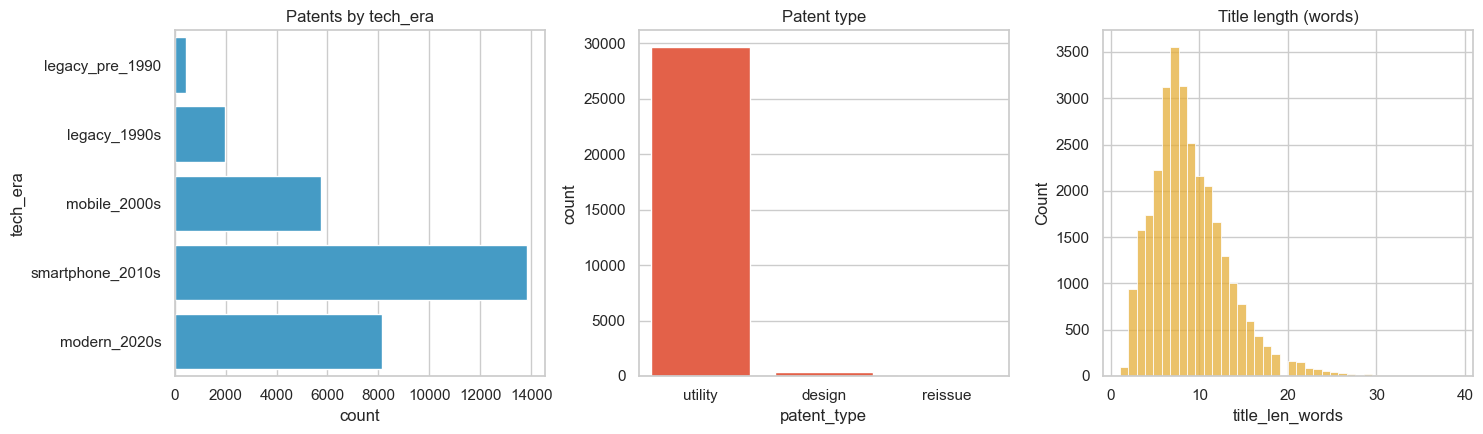

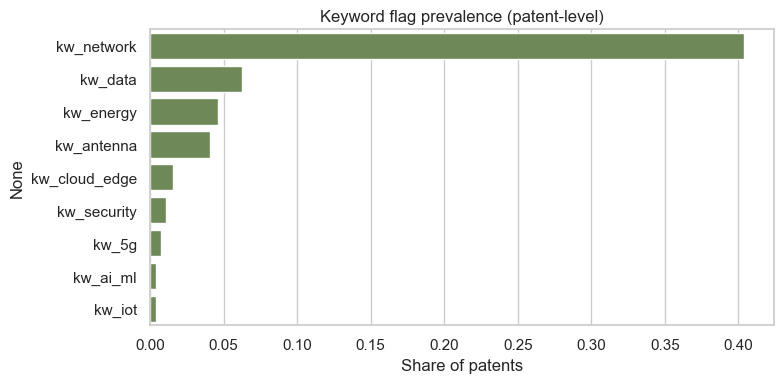

In [5]:
era_order = [
    "legacy_pre_1990", "legacy_1990s", "mobile_2000s", "smartphone_2010s", "modern_2020s",
]
era_order = [e for e in era_order if e in set(df["tech_era"])]
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(data=df, y="tech_era", order=era_order, ax=ax[0], color="#30a2da")
ax[0].set_title("Patents by tech_era")
sns.countplot(data=df, x="patent_type", ax=ax[1], color="#fc4f30")
ax[1].set_title("Patent type")
sns.histplot(df["title_len_words"], bins=40, ax=ax[2], color="#e5ae38")
ax[2].set_title("Title length (words)")
plt.tight_layout()
plt.show()

kw_rate = df[KW_FLAGS].mean().sort_values(ascending=False)
f, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=kw_rate.values, y=kw_rate.index, ax=ax, color="#6d904f")
ax.set_title("Keyword flag prevalence (patent-level)")
ax.set_xlabel("Share of patents")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Era counts reflect both filing intensity and how long each era label spans. Keyword bars show title vocabulary coverage — network is common; 5G/AI are rare absolute events.


# **4. Quarterly Filing Volume:** <a id="Quarter"></a>


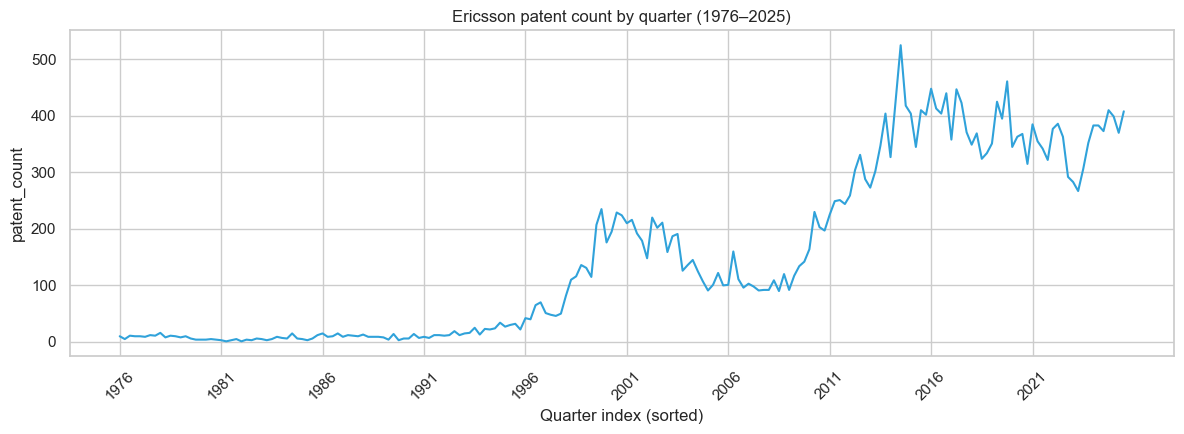

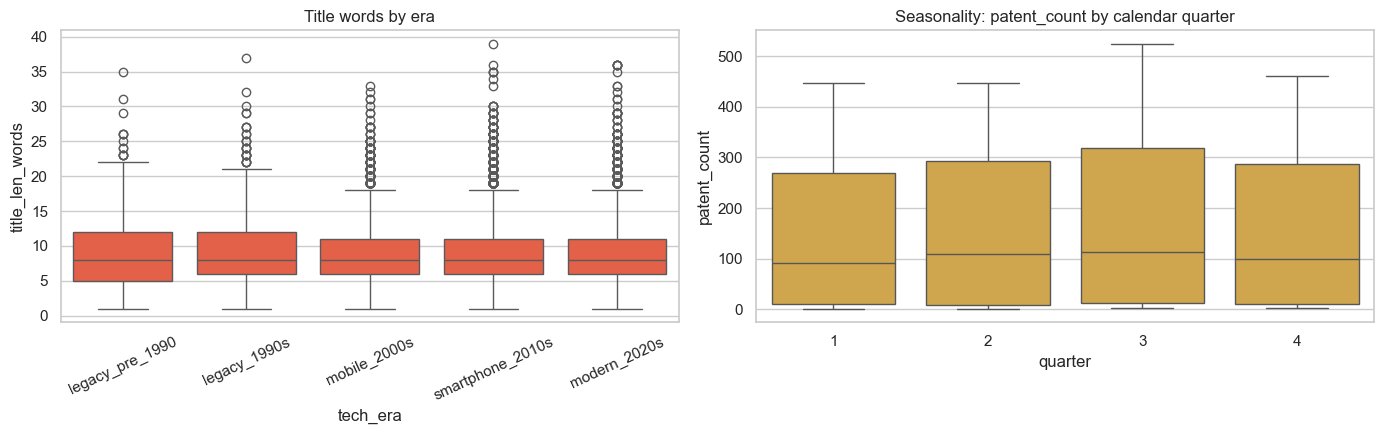

In [6]:
quarter_df = quarter_df.copy()
quarter_df["period"] = pd.PeriodIndex.from_fields(
    year=quarter_df["year"], quarter=quarter_df["quarter"]
).astype(str)

f, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(range(len(quarter_df)), quarter_df["patent_count"], color="#30a2da", lw=1.5)
ax.set_title("Ericsson patent count by quarter (1976–2025)")
ax.set_xlabel("Quarter index (sorted)")
ax.set_ylabel("patent_count")
# light year ticks
year_starts = quarter_df.reset_index().groupby("year")["index"].min()
tick_years = year_starts.index[::5]
ax.set_xticks([year_starts[y] for y in tick_years])
ax.set_xticklabels(tick_years, rotation=45)
plt.tight_layout()
plt.show()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x="tech_era", y="title_len_words", order=era_order, ax=ax[0], color="#fc4f30")
ax[0].set_title("Title words by era")
ax[0].tick_params(axis="x", rotation=25)
sns.boxplot(data=quarter_df, x="quarter", y="patent_count", ax=ax[1], color="#e5ae38")
ax[1].set_title("Seasonality: patent_count by calendar quarter")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
The quarter series is the real innovation-volume clock. Calendar-quarter boxes ask whether Q1–Q4 filing seasonality exists beyond the long-run trend.


# **5. Keyword and Era Trends:** <a id="Keywords"></a>


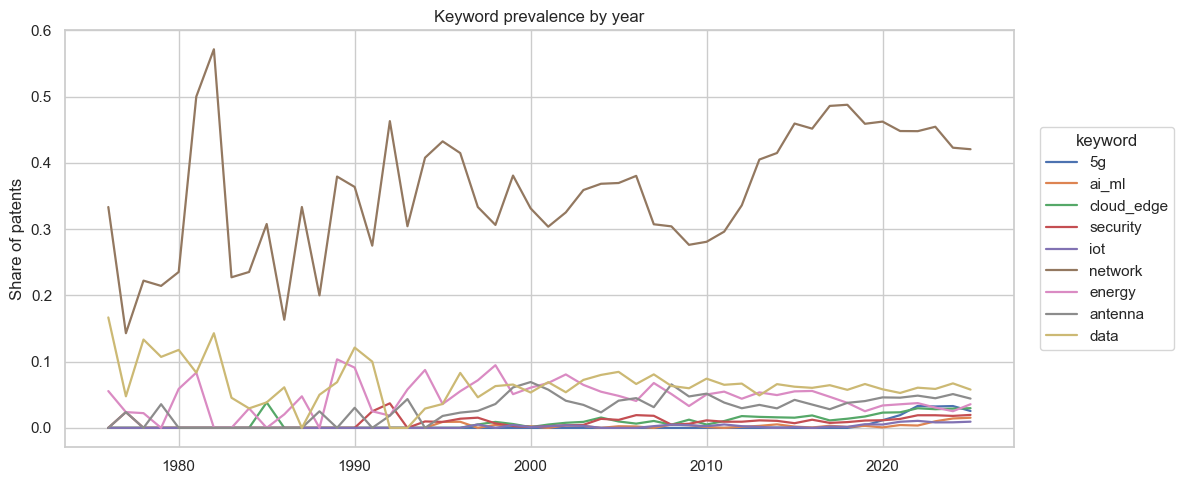

,kw_5g,kw_ai_ml,kw_cloud_edge,kw_security,kw_iot,kw_network,kw_energy,kw_antenna,kw_data
tech_era,,,,,,,,,
smartphone_2010s,0.001,0.002,0.015,0.010,0.002,0.421,0.047,0.036,0.063
modern_2020s,0.026,0.008,0.027,0.017,0.008,0.443,0.033,0.047,0.059


In [7]:
# Annual keyword shares (patent-level rates)
annual = df.groupby("year")[KW_FLAGS].mean()
f, ax = plt.subplots(figsize=(12, 5))
for col in KW_FLAGS:
    ax.plot(annual.index, annual[col], label=col.replace("kw_", ""), lw=1.6)
ax.set_title("Keyword prevalence by year")
ax.set_ylabel("Share of patents")
ax.legend(title="keyword", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

# Focus late eras for sparse modern keywords
modern = df[df["year"] >= 2010]
display(modern.groupby("tech_era")[KW_FLAGS].mean().reindex(
    [e for e in era_order if e in set(modern["tech_era"])]
).round(3))


**How to Interpret:** <br>
Rising 5G / AI / cloud lines in the 2010s–2020s mark title-language shifts. Because flags are title-string heuristics, absence of a keyword is not absence of the technology in the patent body.


# **6. Forecasting Grain Caution:** <a id="Forecast"></a>


corr(current patent_count, next-quarter target): 0.979
corr(lag1, next target): 0.958


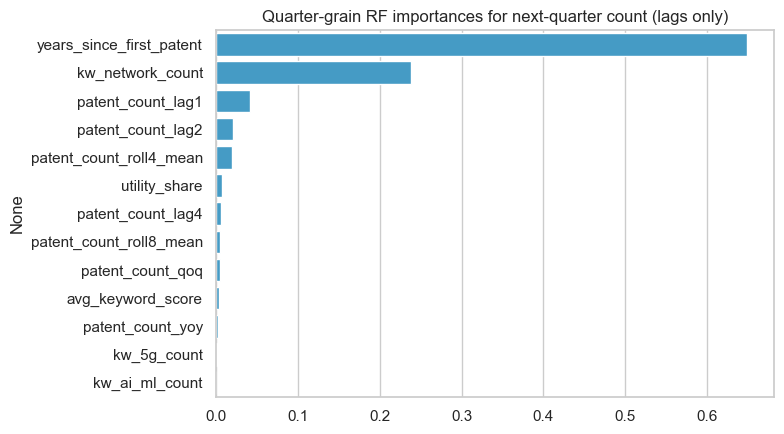

In-sample R^2 (exploratory, not walk-forward): 0.994


In [8]:
q = quarter_df.dropna(subset=["target_patent_count_next_quarter"]).copy()
assert len(q) >= 190
# Naive leakage demo: correlating current count with next target is fine historically,
# but using current patent_count as a "feature" without lag discipline overstates skill.
print("corr(current patent_count, next-quarter target):",
      round(q["patent_count"].corr(q["target_patent_count_next_quarter"]), 3))
print("corr(lag1, next target):",
      round(q["patent_count_lag1"].corr(q["target_patent_count_next_quarter"]), 3)
      if "patent_count_lag1" in q.columns else "n/a")

# Safe-ish feature set for a toy RF at quarter grain
feat_candidates = [
    c for c in [
        "patent_count_lag1", "patent_count_lag2", "patent_count_lag4",
        "patent_count_roll4_mean", "patent_count_roll8_mean",
        "patent_count_qoq", "patent_count_yoy", "years_since_first_patent",
        "utility_share", "avg_keyword_score",
        "kw_5g_count", "kw_ai_ml_count", "kw_network_count",
    ] if c in q.columns
]
# Explicitly exclude leakage columns
leak = {"patent_count", "target_patent_count_current", "target_patent_count_next_quarter"}
assert not (set(feat_candidates) & leak)

X = q[feat_candidates].astype(float)
y = q["target_patent_count_next_quarter"].astype(float)
assert X.notna().all().all(), X.isna().sum().sort_values(ascending=False).head()
rf = RandomForestRegressor(n_estimators=200, random_state=7, max_depth=8, n_jobs=-1)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=feat_candidates).sort_values(ascending=False)
f, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#30a2da")
ax.set_title("Quarter-grain RF importances for next-quarter count (lags only)")
plt.tight_layout()
plt.show()
print("In-sample R^2 (exploratory, not walk-forward):", round(rf.score(X, y), 3))


**How to Interpret:** <br>
This RF is a grain-correct toy — still in-sample, not a walk-forward forecast. Current-quarter `patent_count` / `target_patent_count_current` were excluded so the model cannot cheat with the present.


# **7. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
Patent-level Ericsson filings with duplicated quarterly aggregates and title-keyword flags over ~50 years.

**Working takeaways:** <br>
- Always dedupe to quarter grain for volume and forecasting.
- Keyword trends are title heuristics; network dominates, modern tags rise late.
- Exclude same-quarter targets/counts when framing next-quarter predictors.

**Open follow-ups:** <br>
- Seasonal decomposition / walk-forward validation on `quarter_df`.
- Topic models on `patent_title` beyond the binary keyword flags.
